In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, roc_auc_score, precision_score, recall_score, roc_curve

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
df= pd.read_csv("diabetic_data.csv")

In [ ]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print(df.describe())
print(df.shape)
print(df.info())
print(df.isnull().sum())

       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%                    1.000000             7.00000

In [ ]:
df.replace('?', np.nan, inplace=True)
df.drop(columns=['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty','max_glu_serum','A1Cresult'], inplace=True)
df.dropna(inplace=True)

In [ ]:
print(df.isnull().sum())

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide                  0
examide                     0
citoglipto

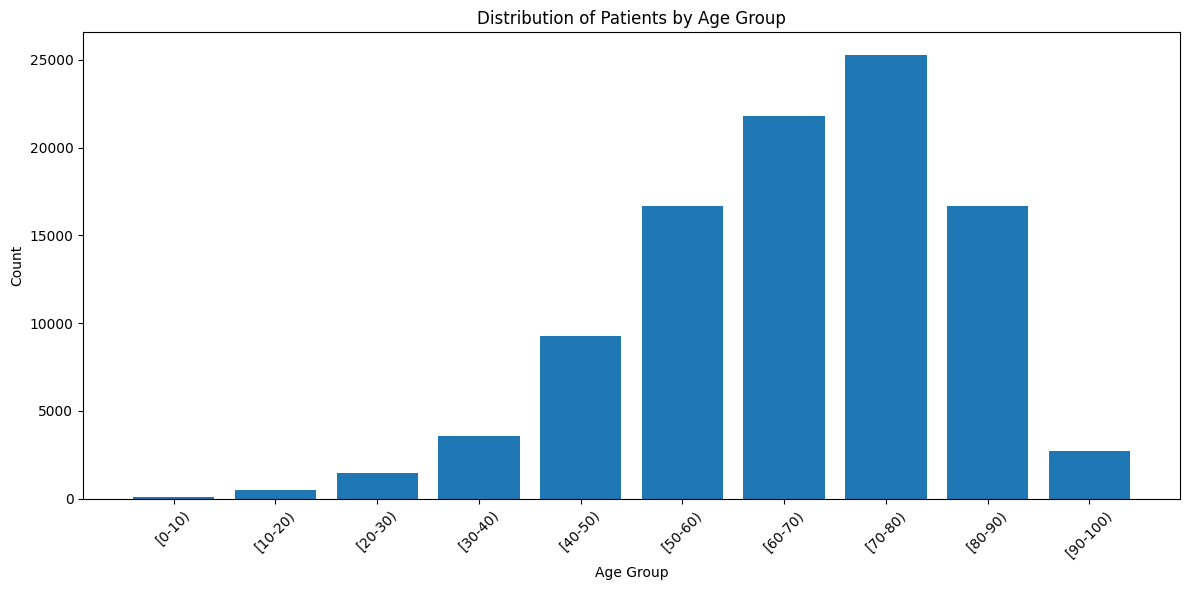

In [ ]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

plt.figure(figsize=(12, 6))
age_counts = df['age'].value_counts().reindex(age_order)
plt.bar(range(len(age_counts)), age_counts.values)
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Distribution of Patients by Age Group')
plt.xticks(range(len(age_counts)), age_counts.index, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import re

def range_to_mean(string_range):
    np_range = np.array(re.findall(r'\d+', string_range))
    np_range = np.asarray(np_range,float)

    return np_range.mean()

df.age = df.age.apply(range_to_mean)

In [ ]:
def diagnoses_mapping(df, columns):
    for col in columns:
        # Convert to string first to safely handle 'V', 'E', and missing codes
        s = df[col].astype(str)

        # Define the regex conditions matching the R code
        conditions = [
            s.str.contains(r'^39[0-9]|^4[0-5][0-9]|^785', regex=True),
            s.str.contains(r'^4[6-9][0-9]|^5[0-1][0-9]|^786', regex=True),
            s.str.contains(r'^5[2-7][0-9]|^787', regex=True),
            s.str.contains(r'^250', regex=True),
            s.str.contains(r'^8|^9', regex=True),
            s.str.contains(r'^7[1-3][0-9]', regex=True),
            s.str.contains(r'^5[8-9][0-9]|^6[0-2][0-9]|^788', regex=True),
            s.str.contains(r'^1[4-9][0-9]|^2[0-3][0-9]', regex=True)
        ]

        # Define the corresponding 8 categories
        choices = [
            'Circulatory',
            'Respiratory',
            'Digestive',
            'Diabetes',
            'Injury',
            'Musculoskeletal',
            'Genitourinary',
            'Neoplasms'
        ]

        # Overwrite the column: if a condition is met, assign the choice. Otherwise, 'Other'
        df[col] = np.select(conditions, choices, default='Other')

    return df

diag_columns = ['diag_1', 'diag_2', 'diag_3']
df = diagnoses_mapping(df, diag_columns)


In [ ]:
drug_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-pioglitazone'
]

df[drug_cols] = df[drug_cols].replace({
    'No': 0,
    'Steady': 1,
    'Up': 2,
    'Down': 3
})

/tmp/ipykernel_558/1534741820.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[drug_cols] = df[drug_cols].replace({


In [ ]:
threshold = 0.85
corr_matrix = df.corr(numeric_only=True)

high_corr = (
    corr_matrix.abs()
    .where(~np.eye(len(corr_matrix), dtype=bool))
    .stack()
)

print(high_corr[high_corr > 0.8])

Series([], dtype: float64)


In [ ]:
df['readmitted'].value_counts()

,count
readmitted,
NO,52338
>30,34649
<30,11066


In [ ]:
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

In [ ]:
print(df['readmitted'].value_counts())

readmitted
0    86987
1    11066
Name: count, dtype: int64


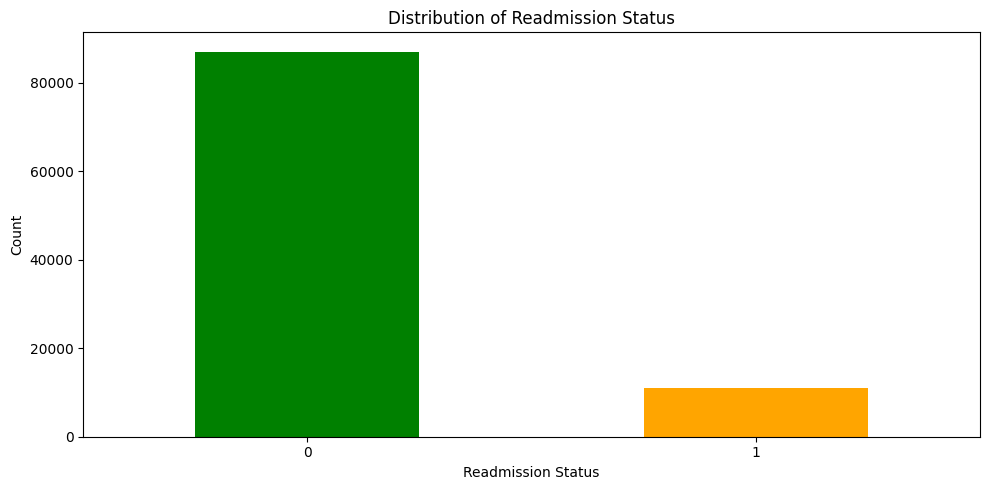

In [ ]:
plt.figure(figsize=(10, 5))
df['readmitted'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.title('Distribution of Readmission Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df['total_utilization'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_utilization
1,Caucasian,Female,15.0,1,1,7,3,59,0,18,...,2,0,0,0,No,0,Ch,Yes,0,0
2,AfricanAmerican,Female,25.0,1,1,7,2,11,5,13,...,0,0,0,0,No,0,No,Yes,0,3
3,Caucasian,Male,35.0,1,1,7,2,44,1,16,...,2,0,0,0,No,0,Ch,Yes,0,0
4,Caucasian,Male,45.0,1,1,7,1,51,0,8,...,1,0,0,0,No,0,Ch,Yes,0,0
5,Caucasian,Male,55.0,2,1,2,3,31,6,16,...,1,0,0,0,No,0,No,Yes,0,0


In [ ]:
X = df_encoded.drop(['readmitted'], axis=1)
y = df_encoded['readmitted']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1, stratify=y)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 7.861030223918064


In [ ]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

predictions = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)

print(accuracy)

0.8849683867020192


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94      8699
           1       0.38      0.03      0.06      1107

    accuracy                           0.88      9806
   macro avg       0.64      0.51      0.50      9806
weighted avg       0.83      0.88      0.84      9806



In [ ]:
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Precision: 0.3820
Recall: 0.0307
F1 Score: 0.0569


In [52]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X_train.columns), "feature_columns.pkl")

['feature_columns.pkl']